# HPAI Risk Analysis
**Investment analysis: How does HPAI outbreak exposure compare across major US egg producers?**

This notebook quantifies the geographic HPAI risk profile for the top 9 US egg producers,
with detailed focus on Cal-Maine Foods (CALM) vs. competitors.

| Phase | Focus |
|---|---|
| 1 | Data loading & exploratory analysis |
| 2 | State-level composite risk scoring |
| 3 | Producer exposure analysis |
| 4 | Visualizations (maps, timelines, comparisons) |
| 5 | Seasonal forecast |

*Data sources: USDA APHIS (Feb 2022–May 2026), WOAH outbreak database, CALM 10-K filings*


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.1f}'.format)
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11, 'figure.figsize': (12, 5)})
sns.set_style('whitegrid')
pio.renderers.default = 'vscode'

STATE_ABBREV = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR',
    'California':'CA','Colorado':'CO','Connecticut':'CT','Delaware':'DE',
    'Florida':'FL','Georgia':'GA','Hawaii':'HI','Idaho':'ID',
    'Illinois':'IL','Indiana':'IN','Iowa':'IA','Kansas':'KS',
    'Kentucky':'KY','Louisiana':'LA','Maine':'ME','Maryland':'MD',
    'Massachusetts':'MA','Michigan':'MI','Minnesota':'MN','Mississippi':'MS',
    'Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV',
    'New Hampshire':'NH','New Jersey':'NJ','New Mexico':'NM','New York':'NY',
    'North Carolina':'NC','North Dakota':'ND','Ohio':'OH','Oklahoma':'OK',
    'Oregon':'OR','Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC',
    'South Dakota':'SD','Tennessee':'TN','Texas':'TX','Utah':'UT',
    'Vermont':'VT','Virginia':'VA','Washington':'WA','West Virginia':'WV',
    'Wisconsin':'WI','Wyoming':'WY'
}
ABBREV_STATE = {v: k for k, v in STATE_ABBREV.items()}

print("Environment ready.")


Environment ready.


## Phase 1 — Data Loading & Exploratory Analysis

In [15]:
# ── Load primary outbreak dataset ─────────────────────────────────────────────
df = pd.read_excel('Outbreak_Data_Cleaned.xlsx', sheet_name='Clean Data')
df.columns = ['date', 'state', 'county', 'special_id', 'production', 'birds_affected']

# Date and state are sparse (shown only once per group); forward-fill both
df['date']  = df['date'].ffill()
df['state'] = df['state'].ffill()

df['date'] = pd.to_datetime(df['date'], format='%d-%b-%y', errors='coerce')
df = df.dropna(subset=['date', 'state'])
df['birds_affected'] = pd.to_numeric(df['birds_affected'], errors='coerce').fillna(0)
df['year']       = df['date'].dt.year
df['month']      = df['date'].dt.month
df['month_str']  = df['date'].dt.strftime('%b')
df['month_year'] = df['date'].dt.to_period('M')
df['season']     = df['month'].map({
    12:'Winter', 1:'Winter',  2:'Winter',
     3:'Spring', 4:'Spring',  5:'Spring',
     6:'Summer', 7:'Summer',  8:'Summer',
     9:'Fall',  10:'Fall',   11:'Fall'
})
df['is_commercial'] = ~df['production'].str.contains('Non-Poultry|Backyard', na=False, case=False)

print(f"Loaded {len(df):,} outbreak records  |  {df['date'].min().date()} → {df['date'].max().date()}")
print(f"States: {df['state'].nunique()}  |  Counties: {df['county'].nunique()}")
print(f"Total birds affected: {df['birds_affected'].sum():,.0f}")
print()
print("Production types:")
print(df['production'].value_counts().to_string())


Loaded 2,204 outbreak records  |  2022-02-08 → 2026-05-01
States: 51  |  Counties: 644
Total birds affected: 206,410,411

Production types:
production
WOAH Non-Poultry                                  841
Commercial Turkey Meat Bird                       501
WOAH Poultry                                      273
Commercial Table Egg Layer                        135
Commercial Broiler Production                      84
Commercial Duck Meat Bird                          83
Live Bird Market                                   75
Commercial Turkey Breeder Hens                     42
Commercial Duck Breeder                            42
Commercial Upland Gamebird Producer                27
Commercial Table Egg Pullets                       26
Commercial Broiler Breeder                         24
Commercial Raised for Release Upland Game Bird     12
Commercial Breeder Operation                        9
Commercial Turkey Breeder Replacement Hens          8
Commercial Broiler Breeder Pullets     

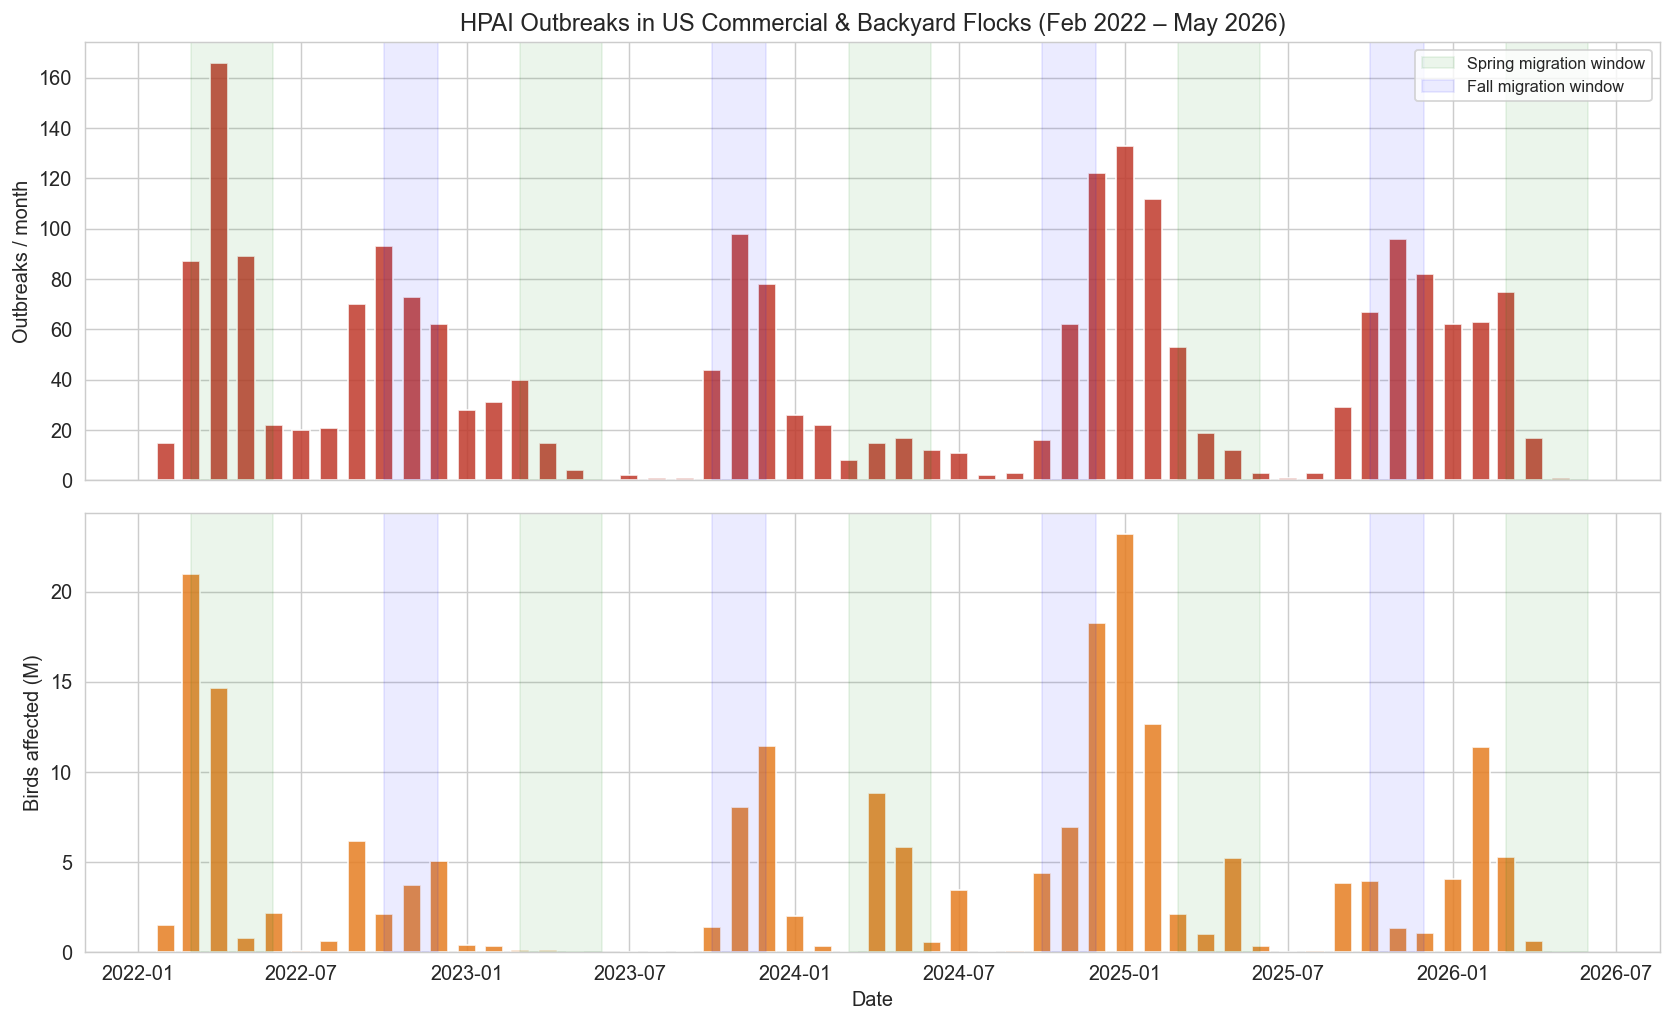

In [16]:
# ── Monthly outbreak count ─────────────────────────────────────────────────────
monthly = (df.groupby('month_year')
             .agg(outbreaks=('date','count'), birds=('birds_affected','sum'))
             .reset_index())
monthly['month_year_dt'] = monthly['month_year'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Top: outbreak count
axes[0].bar(monthly['month_year_dt'], monthly['outbreaks'], color='#C0392B', width=20, alpha=0.85)
axes[0].set_ylabel('Outbreaks / month')
axes[0].set_title('HPAI Outbreaks in US Commercial & Backyard Flocks (Feb 2022 – May 2026)')
axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Bottom: birds affected (millions)
axes[1].bar(monthly['month_year_dt'], monthly['birds'] / 1e6, color='#E67E22', width=20, alpha=0.85)
axes[1].set_ylabel('Birds affected (M)')
axes[1].set_xlabel('Date')

# Annotate migration seasons
for ax in axes:
    ax.axvspan(pd.Timestamp('2022-03-01'), pd.Timestamp('2022-05-31'), alpha=0.08, color='green', label='Spring migration')
    ax.axvspan(pd.Timestamp('2022-10-01'), pd.Timestamp('2022-11-30'), alpha=0.08, color='blue', label='Fall migration')
    for yr in [2023, 2024, 2025, 2026]:
        ax.axvspan(pd.Timestamp(f'{yr}-03-01'), pd.Timestamp(f'{yr}-05-31'), alpha=0.08, color='green')
        if yr <= 2025:
            ax.axvspan(pd.Timestamp(f'{yr}-10-01'), pd.Timestamp(f'{yr}-11-30'), alpha=0.08, color='blue')

axes[0].legend(['Spring migration window', 'Fall migration window'], loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


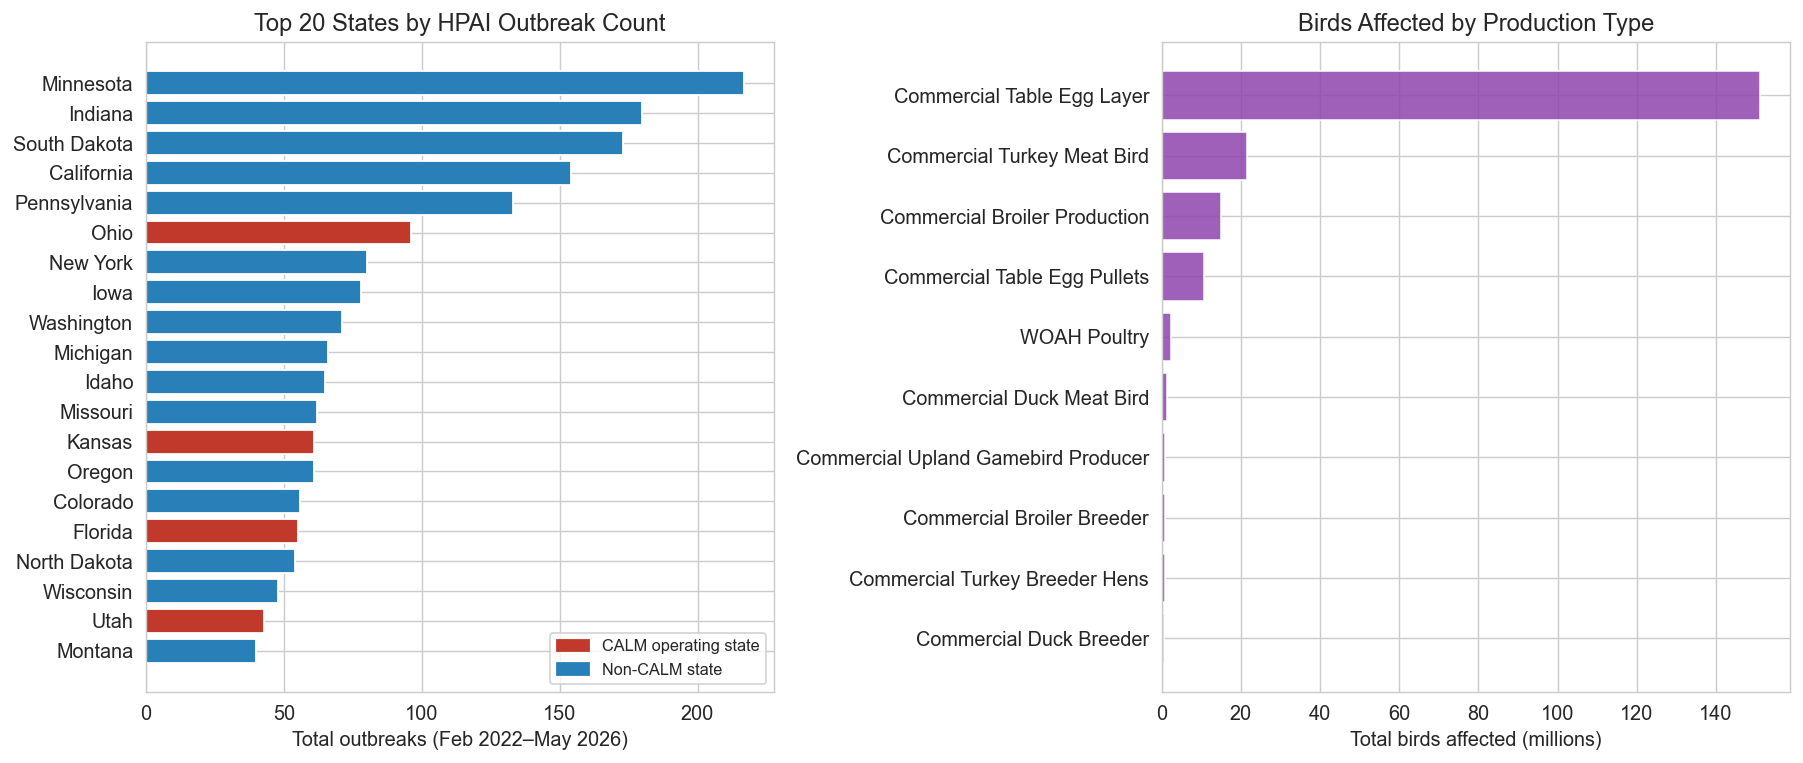


Top 5 states by total birds affected:
state
Iowa            30,748,844
Ohio            25,362,926
California      24,192,202
Pennsylvania    15,953,180
Wisconsin       11,631,834


In [17]:
CALM_STATES_FULL = {
    'Alabama','Arkansas','Florida','Georgia','Kansas','Kentucky','Louisiana',
    'Maryland','Mississippi','New Jersey','Ohio','Oklahoma','South Carolina','Texas','Utah'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: top 20 states by outbreak count, CALM states highlighted
state_counts = df.groupby('state').agg(
    outbreaks=('date','count'),
    birds=('birds_affected','sum')
).reset_index().sort_values('outbreaks', ascending=False).head(20)

colors = ['#C0392B' if s in CALM_STATES_FULL else '#2980B9' for s in state_counts['state']]
axes[0].barh(state_counts['state'][::-1], state_counts['outbreaks'][::-1], color=colors[::-1])
axes[0].set_xlabel('Total outbreaks (Feb 2022–May 2026)')
axes[0].set_title('Top 20 States by HPAI Outbreak Count')

calm_patch  = mpatches.Patch(color='#C0392B', label='CALM operating state')
other_patch = mpatches.Patch(color='#2980B9', label='Non-CALM state')
axes[0].legend(handles=[calm_patch, other_patch], fontsize=9)

# Right: birds affected by production type (top 10)
prod_birds = (df.groupby('production')['birds_affected'].sum()
               .sort_values(ascending=False).head(10))
axes[1].barh(prod_birds.index[::-1], prod_birds.values[::-1] / 1e6, color='#8E44AD', alpha=0.85)
axes[1].set_xlabel('Total birds affected (millions)')
axes[1].set_title('Birds Affected by Production Type')

plt.tight_layout()
plt.show()

print(f"\nTop 5 states by total birds affected:")
print(df.groupby('state')['birds_affected'].sum()
        .sort_values(ascending=False).head(5)
        .apply(lambda x: f'{x:,.0f}').to_string())


In [18]:
# ── Load competitor/producer data ─────────────────────────────────────────────

# Main producer list
df_producers = pd.read_excel('CALM-Competitor-Geographic-Diversity.xlsx', sheet_name='Main', header=1)
df_producers = df_producers[df_producers['Company'].notna()].copy()
df_producers = df_producers[~df_producers['Company'].str.contains('Total|Sheets', na=False)]
df_producers = df_producers.rename(columns={'#':'rank','Company':'company','Layers (M)':'layers_M',
                                             'States':'state_count','Egg Laying States':'egg_states'})
print("=== Top 9 US Egg Producers ===")
print(df_producers[['rank','company','layers_M','state_count','egg_states']].to_string(index=False))

# State presence matrix (binary)
df_matrix = pd.read_excel(
    'CALM-Competitor-Geographic-Diversity.xlsx',
    sheet_name='State Matrix',
    header=3,
    usecols=list(range(10))
)
df_matrix.columns = ['state','Cal-Maine','Versova Coop','Rose Acre','Daybreak',
                     'Global Eggs','Mid-States','MPS','Michael Foods','Vital Farms']
df_matrix = df_matrix.dropna(subset=['state'])
PRODUCER_COLS = [c for c in df_matrix.columns if c != 'state']
for col in PRODUCER_COLS:
    df_matrix[col] = pd.to_numeric(df_matrix[col], errors='coerce').fillna(0).astype(int)

print(f"\nState matrix loaded: {len(df_matrix)} states × {len(PRODUCER_COLS)} producers")

# CALM facilities detail
df_facilities = pd.read_excel(
    'CALM-Competitor-Geographic-Diversity.xlsx',
    sheet_name='Cal-Maine facilities',
    header=3
)
df_facilities.columns = ['facility_type','count','capacity','states','notes']
df_facilities = df_facilities.dropna(subset=['facility_type'])
df_facilities = df_facilities[df_facilities['facility_type'].str.contains('Shell egg|Pullet|Processing|Feed mill|Hatch|Breed|Egg product', na=False)]
print("\n=== Cal-Maine Facility Breakdown ===")
print(df_facilities[['facility_type','count','states']].to_string(index=False))


=== Top 9 US Egg Producers ===
 rank                                company  layers_M  state_count                                                 egg_states
  1.0                        Cal-Maine Foods      51.5         15.0 AL, AR, FL, GA, KS, KY, LA, MD, MS, NJ, OH, OK, SC, TX, UT
  2.0         Versova Management Cooperative      30.0          4.0                                             IA, OH, WA, OR
  3.0                        Rose Acre Farms      25.5          7.0                                 IN, IL, MO, NC, GA, IA, AZ
  4.0                         Daybreak Foods      23.3          3.0                                                 IA, WI, OH
  5.0 Global Eggs (US Division) / Hillandale      21.0          5.0                                         PA, OH, CT, IA, ME
  6.0              Mid-States Specialty Eggs      15.0          2.0                                                     MO, AK
  7.0                          MPS Egg Farms      14.0          2.0             

## Phase 2 — State-Level Risk Scoring

Each state receives a **composite risk score (0–100)** derived from four components:

| Weight | Component | What it captures |
|---|---|---|
| 35% | Intensity | Log-scaled total birds affected |
| 30% | Frequency | Total outbreak count |
| 25% | Recency | Exponentially-decayed recent activity (half-life = 1 yr) |
| 10% | Trend | Whether outbreaks are accelerating or declining |


In [19]:
reference_date = df['date'].max()

# Per-state base stats
state_stats = df.groupby('state').agg(
    outbreak_count=('date', 'count'),
    birds_affected=('birds_affected', 'sum'),
    latest_outbreak=('date', 'max'),
).reset_index()

# Recency score: sum exp(-days_since / 365)
def recency_score(dates, ref=reference_date):
    days_since = (ref - dates).dt.days.clip(lower=0)
    return float(np.exp(-days_since / 365).sum())

recency = df.groupby('state')['date'].apply(recency_score).reset_index(name='recency_raw')
state_stats = state_stats.merge(recency, on='state', how='left')

# Trend: slope of annual outbreak counts (outbreaks per year)
annual = df.groupby(['state', 'year']).size().reset_index(name='count')

def annual_slope(grp):
    if len(grp) < 2:
        return 0.0
    return float(np.polyfit(grp['year'].values, grp['count'].values, 1)[0])

trend = annual.groupby('state').apply(annual_slope).reset_index(name='trend_raw')
state_stats = state_stats.merge(trend, on='state', how='left')
state_stats['trend_raw'] = state_stats['trend_raw'].fillna(0)

# Normalize each component to 0–1
def norm01(s):
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo) if hi > lo else s * 0.0

state_stats['freq_norm']      = norm01(state_stats['outbreak_count'])
state_stats['intensity_norm'] = norm01(np.log1p(state_stats['birds_affected']))
state_stats['recency_norm']   = norm01(state_stats['recency_raw'])
state_stats['trend_norm']     = norm01(state_stats['trend_raw'].clip(lower=0))

# Composite score 0–100
state_stats['composite_risk'] = (
    0.35 * state_stats['intensity_norm'] +
    0.30 * state_stats['freq_norm'] +
    0.25 * state_stats['recency_norm'] +
    0.10 * state_stats['trend_norm']
) * 100

state_stats = state_stats.sort_values('composite_risk', ascending=False).reset_index(drop=True)
state_stats['state_abbrev'] = state_stats['state'].map(STATE_ABBREV)
state_stats['risk_tier'] = pd.cut(state_stats['composite_risk'],
                                   bins=[0, 25, 50, 75, 100],
                                   labels=['Low (<25)', 'Moderate (25–50)',
                                           'High (50–75)', 'Critical (>75)'],
                                   include_lowest=True)

print("=== Top 20 States by Composite Risk Score ===")
display_cols = ['state','composite_risk','risk_tier','outbreak_count','birds_affected','latest_outbreak']
print(state_stats[display_cols].head(20).to_string(index=False))


=== Top 20 States by Composite Risk Score ===
         state  composite_risk        risk_tier  outbreak_count  birds_affected latest_outbreak
       Indiana            91.9   Critical (>75)             180        10350897      2026-04-08
     Minnesota            69.4     High (50–75)             217        10395483      2026-04-17
  South Dakota            62.8     High (50–75)             173         8025670      2026-04-27
    California            62.5     High (50–75)             154        24192202      2026-02-09
  Pennsylvania            60.8     High (50–75)             133        15953180      2026-04-01
          Ohio            56.6     High (50–75)              96        25362926      2026-03-17
          Iowa            48.9 Moderate (25–50)              78        30748844      2026-03-05
      Michigan            44.0 Moderate (25–50)              66         7700827      2026-03-13
    Washington            42.6 Moderate (25–50)              71         4133418      2026-

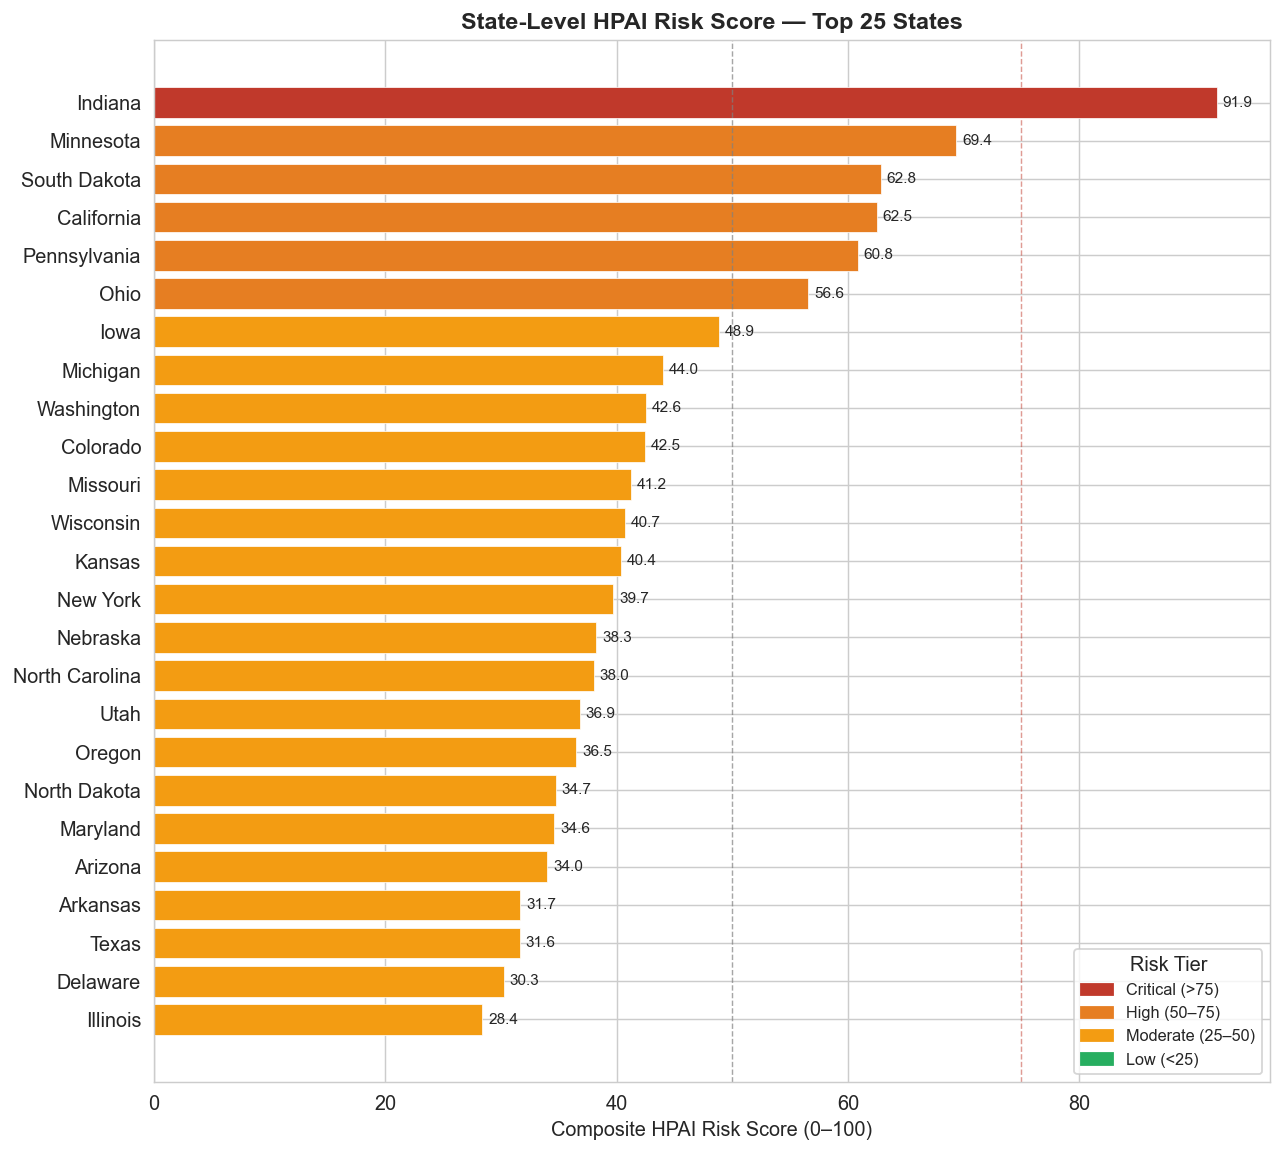

In [20]:
# ── Horizontal bar: top 25 states by risk score ────────────────────────────────
top_n = state_stats.head(25).iloc[::-1]

tier_colors = {
    'Critical (>75)':   '#C0392B',
    'High (50–75)':     '#E67E22',
    'Moderate (25–50)': '#F39C12',
    'Low (<25)':        '#27AE60',
}
bar_colors = [tier_colors.get(str(t), '#95A5A6') for t in top_n['risk_tier']]

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(top_n['state'], top_n['composite_risk'], color=bar_colors, edgecolor='white', linewidth=0.4)
ax.set_xlabel('Composite HPAI Risk Score (0–100)')
ax.set_title('State-Level HPAI Risk Score — Top 25 States', fontsize=13, fontweight='bold')
ax.axvline(50, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axvline(75, color='#C0392B', linestyle='--', linewidth=0.8, alpha=0.5)

for bar, val in zip(bars, top_n['composite_risk']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', ha='left', fontsize=8.5)

legend_patches = [plt.Rectangle((0,0),1,1, color=c, label=t) for t, c in tier_colors.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9, title='Risk Tier')
plt.tight_layout()
plt.show()


## Phase 3 — Producer Exposure Analysis

Map each producer's **state presence** against the risk scores to compute:
- **Total exposure**: sum of risk scores across all states where the producer operates
- **Avg risk per state**: mean risk score across operating states (diversification quality)
- **High-risk states**: count of states with risk > 50


In [21]:
# ── Join state matrix with risk scores ────────────────────────────────────────
df_matrix_risk = df_matrix.merge(
    state_stats[['state', 'composite_risk', 'risk_tier']],
    on='state', how='left'
)
df_matrix_risk['composite_risk'] = df_matrix_risk['composite_risk'].fillna(0)

# ── Build exposure table ───────────────────────────────────────────────────────
rows = []
for prod in PRODUCER_COLS:
    mask = df_matrix_risk[prod] == 1
    present = df_matrix_risk.loc[mask, 'composite_risk']
    rows.append({
        'Producer':           prod,
        'States':             int(mask.sum()),
        'Total Exposure':     round(present.sum(), 1),
        'Avg Risk/State':     round(present.mean(), 1) if len(present) else 0,
        'Max State Risk':     round(present.max(), 1) if len(present) else 0,
        'High-Risk States':   int((present >= 50).sum()),
        'Critical States':    int((present >= 75).sum()),
    })

df_exposure = pd.DataFrame(rows).sort_values('Total Exposure', ascending=False).reset_index(drop=True)
df_exposure.index = df_exposure.index + 1
df_exposure.index.name = 'Rank'

print("=== Producer HPAI Exposure Ranking ===")
print(df_exposure.to_string())

# ── CALM state-level breakdown ─────────────────────────────────────────────────
calm_abbrevs = ['AL','AR','FL','GA','KS','KY','LA','MD','MS','NJ','OH','OK','SC','TX','UT']
calm_states  = [ABBREV_STATE[a] for a in calm_abbrevs if a in ABBREV_STATE]

calm_detail = state_stats[state_stats['state'].isin(calm_states)][
    ['state','state_abbrev','composite_risk','risk_tier','outbreak_count','birds_affected']
].sort_values('composite_risk', ascending=False).reset_index(drop=True)

print("\n=== Cal-Maine: Risk by Operating State ===")
print(calm_detail.to_string(index=False))


=== Producer HPAI Exposure Ranking ===
           Producer  States  Total Exposure  Avg Risk/State  Max State Risk  High-Risk States  Critical States
Rank                                                                                                          
1         Cal-Maine      15           417.5            27.8            56.6                 1                0
2       Vital Farms      10           373.0            37.3            91.9                 2                1
3         Rose Acre       7           309.2            44.2            91.9                 1                1
4      Versova Coop       4           184.5            46.1            56.6                 1                0
5       Global Eggs       5           182.3            36.5            60.8                 2                0
6     Michael Foods       3           156.5            52.2            69.4                 1                0
7          Daybreak       3           146.2            48.7            56

## Phase 4 — Visualizations

In [22]:
# ── US choropleth: state risk scores + CALM overlay ──────────────────────────
all_states = pd.DataFrame({'state': list(STATE_ABBREV.keys())})
all_states['abbrev'] = all_states['state'].map(STATE_ABBREV)
all_states = all_states.merge(state_stats[['state','composite_risk','outbreak_count','birds_affected']], on='state', how='left')
all_states['composite_risk'] = all_states['composite_risk'].fillna(0)
all_states['calm_presence'] = all_states['state'].isin(calm_states).astype(int)
all_states['hover'] = (
    all_states['state'] + '<br>' +
    'Risk Score: ' + all_states['composite_risk'].round(1).astype(str) + '<br>' +
    'Outbreaks: ' + all_states['outbreak_count'].fillna(0).astype(int).astype(str) + '<br>' +
    'Birds Affected: ' + (all_states['birds_affected'].fillna(0) / 1e6).round(2).astype(str) + 'M' +
    all_states['calm_presence'].map({1: '<br>⭐ CALM OPERATING STATE', 0: ''})
)

fig = px.choropleth(
    all_states,
    locations='abbrev',
    locationmode='USA-states',
    color='composite_risk',
    scope='usa',
    color_continuous_scale='Reds',
    range_color=(0, 100),
    hover_name='hover',
    hover_data={'abbrev': False, 'composite_risk': False},
    title='<b>HPAI Composite Risk Score by State</b>  (darker = higher risk)',
    labels={'composite_risk': 'Risk Score'}
)

# Outline CALM states
calm_trace = px.choropleth(
    all_states[all_states['calm_presence'] == 1],
    locations='abbrev',
    locationmode='USA-states',
    color_discrete_sequence=['rgba(0,0,0,0)'],
    scope='usa'
).data[0]
calm_trace.update(marker_line_color='#1A5276', marker_line_width=2.5)
fig.add_trace(calm_trace)

fig.update_layout(
    height=520,
    coloraxis_colorbar=dict(title='Risk Score', tickvals=[0, 25, 50, 75, 100]),
    annotations=[dict(
        text='Blue borders = Cal-Maine operating states',
        xref='paper', yref='paper', x=0.01, y=-0.02,
        showarrow=False, font=dict(size=10)
    )]
)
fig.show()


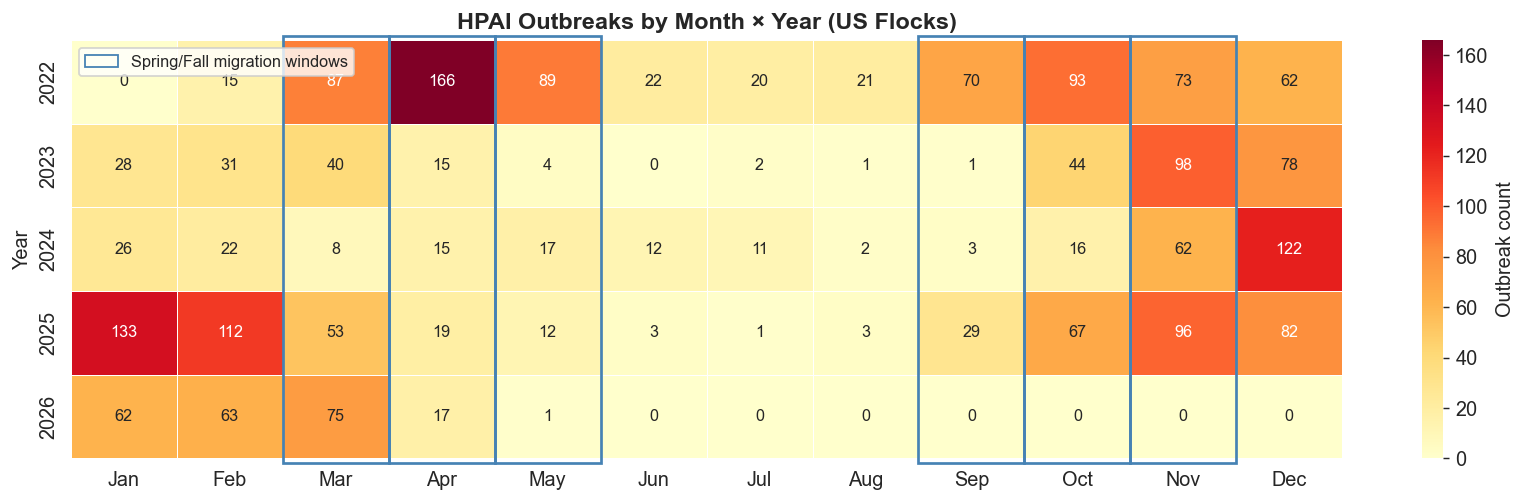

In [23]:
# ── Seasonal heatmap: outbreaks by month × year ───────────────────────────────
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

pivot = (df.groupby(['year','month']).size()
           .reset_index(name='outbreaks')
           .pivot(index='year', columns='month', values='outbreaks')
           .fillna(0)
           .reindex(columns=range(1,13), fill_value=0))
pivot.columns = MONTH_NAMES

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', linewidths=0.4, linecolor='white',
            annot=True, fmt='.0f', annot_kws={'size': 9},
            cbar_kws={'label': 'Outbreak count'})
ax.set_title('HPAI Outbreaks by Month × Year (US Flocks)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Year')

# Shade migration windows
for col_idx in [2, 3, 4, 8, 9, 10]:  # Mar/Apr/May and Sep/Oct/Nov
    ax.add_patch(plt.Rectangle((col_idx, -0.05), 1, len(pivot)+0.1,
                                fill=False, edgecolor='steelblue', lw=1.5, clip_on=False))

import matplotlib.patches as mpatches
spring_patch = mpatches.Patch(fill=False, edgecolor='steelblue', label='Spring/Fall migration windows')
ax.legend(handles=[spring_patch], loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


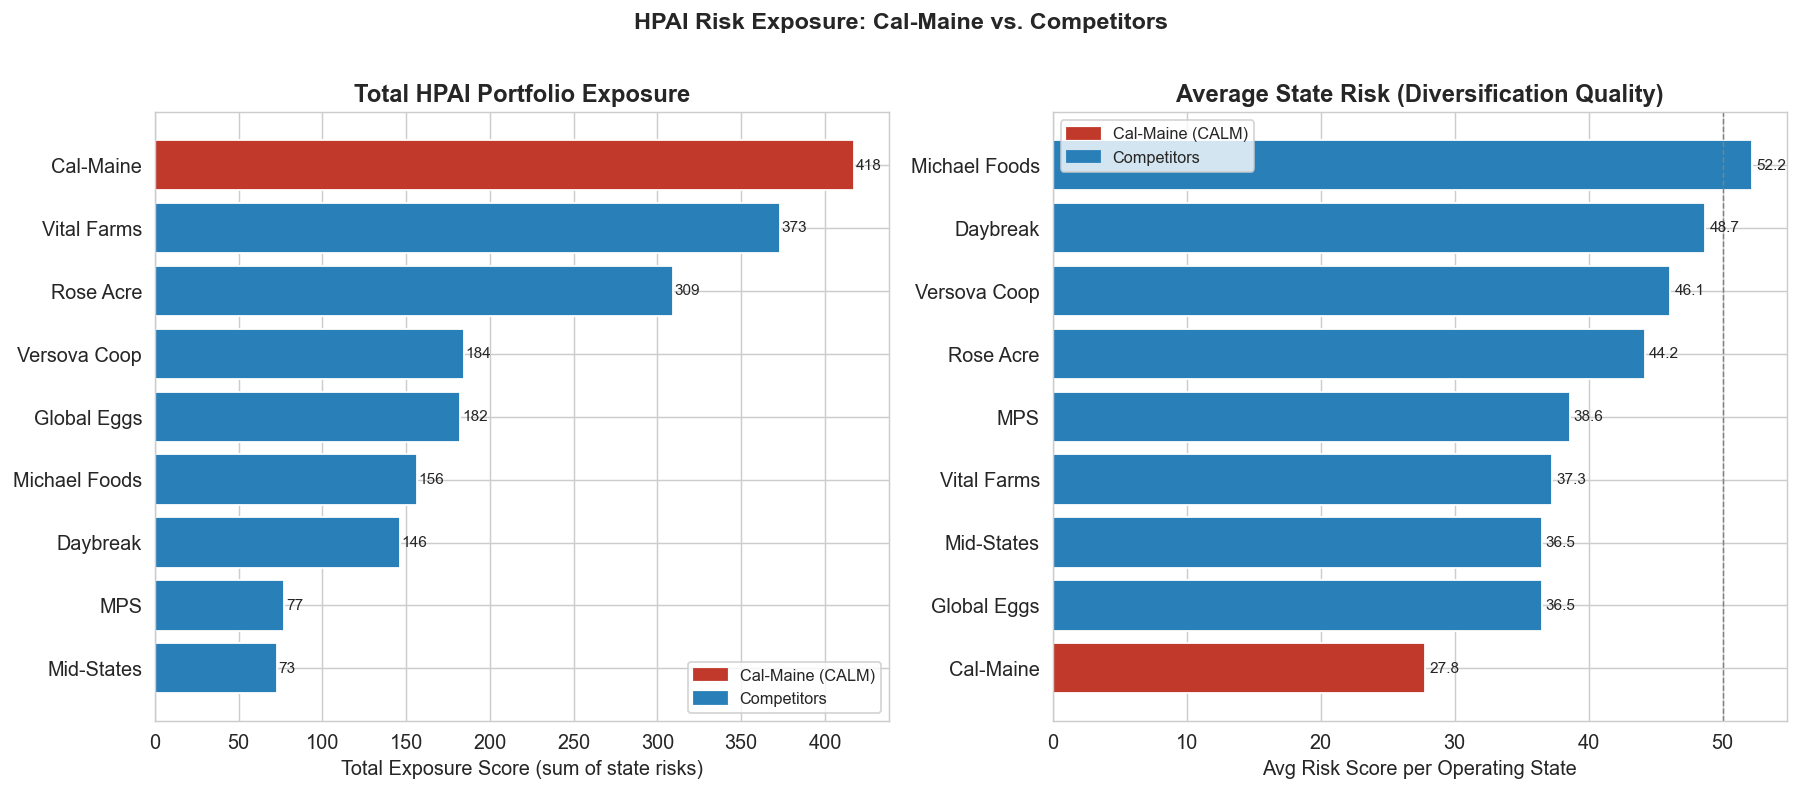

In [24]:
# ── Producer risk exposure comparison ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_prod = ['#C0392B' if p == 'Cal-Maine' else '#2980B9' for p in df_exposure['Producer']]

# Left: Total Exposure
sorted_total = df_exposure.sort_values('Total Exposure')
c1 = ['#C0392B' if p == 'Cal-Maine' else '#2980B9' for p in sorted_total['Producer']]
bars1 = axes[0].barh(sorted_total['Producer'], sorted_total['Total Exposure'], color=c1, edgecolor='white')
for bar, val in zip(bars1, sorted_total['Total Exposure']):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{val:.0f}', va='center', ha='left', fontsize=8.5)
axes[0].set_xlabel('Total Exposure Score (sum of state risks)')
axes[0].set_title('Total HPAI Portfolio Exposure', fontweight='bold')

# Right: Avg Risk Per State (diversification quality)
sorted_avg = df_exposure.sort_values('Avg Risk/State')
c2 = ['#C0392B' if p == 'Cal-Maine' else '#2980B9' for p in sorted_avg['Producer']]
bars2 = axes[1].barh(sorted_avg['Producer'], sorted_avg['Avg Risk/State'], color=c2, edgecolor='white')
for bar, val in zip(bars2, sorted_avg['Avg Risk/State']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', ha='left', fontsize=8.5)
axes[1].set_xlabel('Avg Risk Score per Operating State')
axes[1].set_title('Average State Risk (Diversification Quality)', fontweight='bold')
axes[1].axvline(50, color='grey', linestyle='--', linewidth=0.8)

calm_patch = mpatches.Patch(color='#C0392B', label='Cal-Maine (CALM)')
comp_patch = mpatches.Patch(color='#2980B9', label='Competitors')
for ax in axes:
    ax.legend(handles=[calm_patch, comp_patch], fontsize=9)

plt.suptitle('HPAI Risk Exposure: Cal-Maine vs. Competitors', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


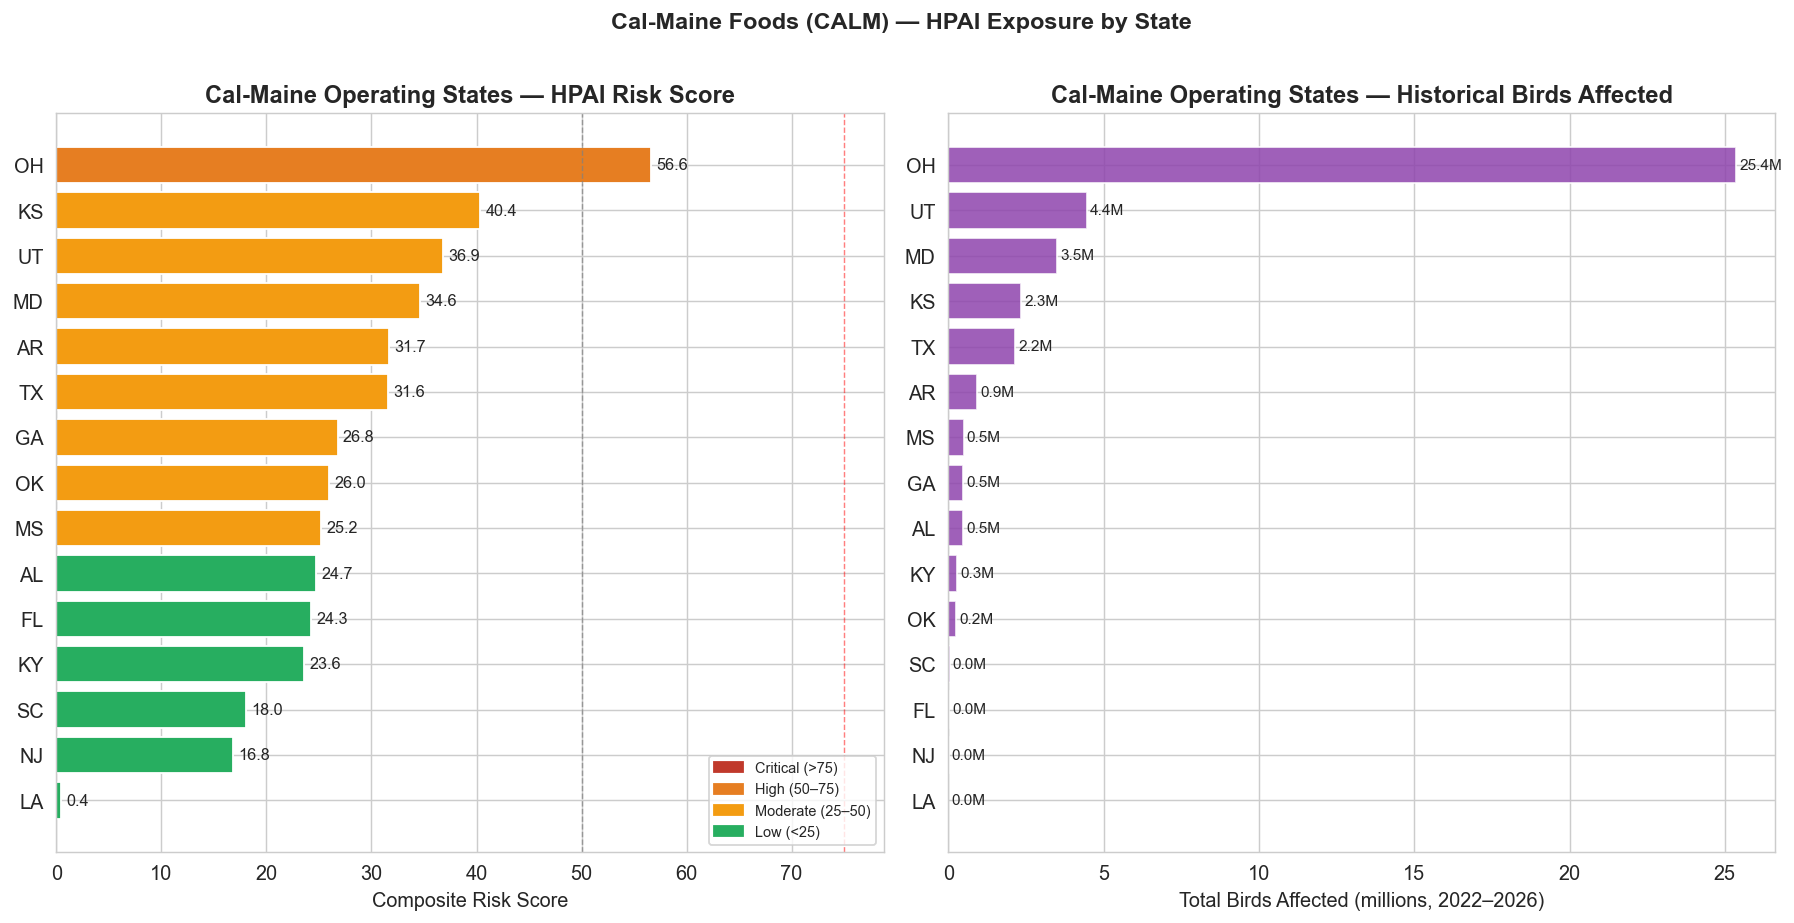

In [25]:
# ── CALM: risk breakdown by operating state ────────────────────────────────────
calm_detail_sorted = calm_detail.sort_values('composite_risk')

tier_colors_map = {
    'Critical (>75)':   '#C0392B',
    'High (50–75)':     '#E67E22',
    'Moderate (25–50)': '#F39C12',
    'Low (<25)':        '#27AE60',
}
bar_colors_calm = [tier_colors_map.get(str(t), '#95A5A6') for t in calm_detail_sorted['risk_tier']]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left: risk scores per CALM state
bars = axes[0].barh(calm_detail_sorted['state_abbrev'], calm_detail_sorted['composite_risk'],
                    color=bar_colors_calm, edgecolor='white')
for bar, val in zip(bars, calm_detail_sorted['composite_risk']):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', ha='left', fontsize=9)
axes[0].set_xlabel('Composite Risk Score')
axes[0].set_title("Cal-Maine Operating States — HPAI Risk Score", fontweight='bold')
axes[0].axvline(50, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
axes[0].axvline(75, color='red',  linestyle='--', linewidth=0.8, alpha=0.5)

legend_patches = [plt.Rectangle((0,0),1,1, color=c, label=t) for t, c in tier_colors_map.items()]
axes[0].legend(handles=legend_patches, fontsize=8, loc='lower right')

# Right: birds affected per CALM state (historical)
calm_detail_birds = calm_detail.sort_values('birds_affected')
axes[1].barh(calm_detail_birds['state_abbrev'], calm_detail_birds['birds_affected'] / 1e6,
             color='#8E44AD', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Total Birds Affected (millions, 2022–2026)')
axes[1].set_title("Cal-Maine Operating States — Historical Birds Affected", fontweight='bold')
for i, (_, row) in enumerate(calm_detail_birds.iterrows()):
    if row['birds_affected'] > 0:
        axes[1].text(row['birds_affected']/1e6 + 0.1, i,
                     f"{row['birds_affected']/1e6:.1f}M", va='center', ha='left', fontsize=8.5)

plt.suptitle("Cal-Maine Foods (CALM) — HPAI Exposure by State", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Phase 5 — Seasonal Forecast

Uses historical seasonal patterns (2022–2026) combined with a year-over-year trend to
project outbreak activity for the next 12 months. The model:

1. Computes average monthly outbreak counts per calendar month
2. Fits a linear trend to annual totals
3. Projects: `forecast = seasonal_avg × (1 + trend_rate) ^ years_ahead`


In [26]:
# ── Seasonal decomposition ─────────────────────────────────────────────────────
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Monthly aggregates
monthly_all = df.groupby(['year','month']).size().reset_index(name='outbreaks')

# Seasonal average per calendar month (all years)
seasonal_avg = monthly_all.groupby('month')['outbreaks'].mean().reindex(range(1,13), fill_value=0)

# Annual totals for trend
annual_totals = df.groupby('year').size().reset_index(name='total')
# Exclude partial years at start/end if needed
years = annual_totals['year'].values
totals = annual_totals['total'].values

trend_coef = np.polyfit(years - years[0], totals, 1)
print(f"Annual trend: {trend_coef[0]:+.1f} outbreaks/year  (baseline {trend_coef[1]:.0f} in {years[0]})")

trend_rate = trend_coef[0] / totals.mean()
print(f"Trend rate: {trend_rate:+.1%} per year")

# Project next 12 months
last_date = df['date'].max()
forecast_months = pd.date_range(
    start=last_date.to_period('M').to_timestamp() + pd.offsets.MonthBegin(1),
    periods=12, freq='MS'
)
years_ahead = [(d.year - last_date.year) + (d.month - last_date.month) / 12 for d in forecast_months]
forecast_values = [
    seasonal_avg[d.month] * (1 + trend_rate) ** yrs
    for d, yrs in zip(forecast_months, years_ahead)
]

df_forecast = pd.DataFrame({
    'date': forecast_months,
    'forecast': forecast_values,
    'month': [d.month for d in forecast_months],
    'season': [('Spring' if m in [3,4,5] else 'Summer' if m in [6,7,8]
                else 'Fall' if m in [9,10,11] else 'Winter')
               for m in [d.month for d in forecast_months]]
})

print("\n=== 12-Month Outbreak Forecast ===")
print(df_forecast[['date','forecast','season']].to_string(index=False))
print(f"\nPeak forecast month: {df_forecast.loc[df_forecast['forecast'].idxmax(), 'date'].strftime('%B %Y')} "
      f"({df_forecast['forecast'].max():.0f} projected outbreaks)")


Annual trend: -73.2 outbreaks/year  (baseline 587 in 2022)
Trend rate: -16.6% per year

=== 12-Month Outbreak Forecast ===
      date  forecast season
2026-06-01      12.1 Summer
2026-07-01       8.2 Summer
2026-08-01       6.5 Summer
2026-09-01      24.2   Fall
2026-10-01      51.0   Fall
2026-11-01      75.1   Fall
2026-12-01      77.4 Winter
2027-01-01      55.2 Winter
2027-02-01      42.4 Winter
2027-03-01      45.2 Spring
2027-04-01      39.3 Spring
2027-05-01      20.5 Spring

Peak forecast month: December 2026 (77 projected outbreaks)


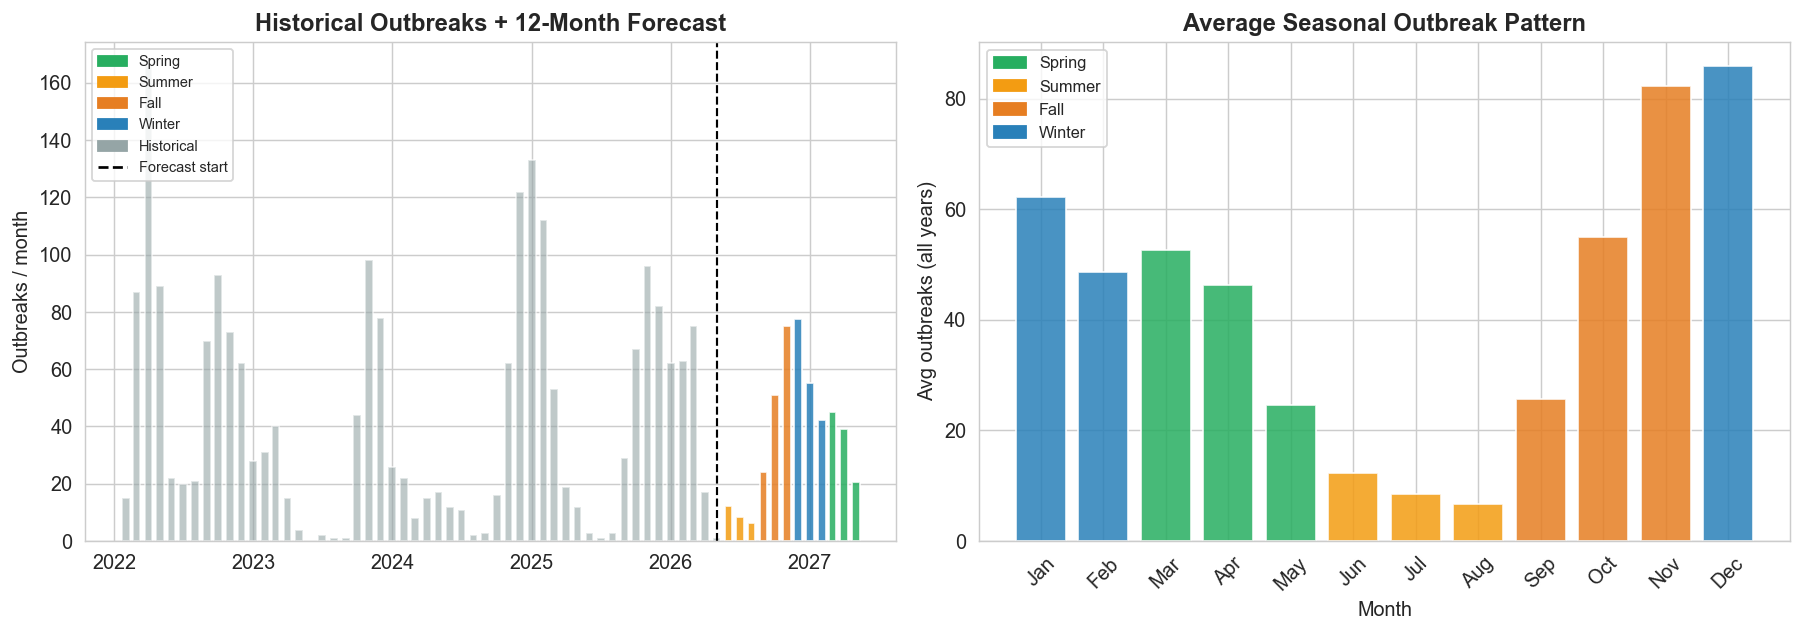

In [27]:
# ── Forecast chart ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: seasonal pattern + forecast overlay
season_colors = {'Spring':'#27AE60','Summer':'#F39C12','Fall':'#E67E22','Winter':'#2980B9'}

hist_monthly = monthly_all.copy()
hist_monthly['date_ts'] = pd.to_datetime(
    hist_monthly['year'].astype(str) + '-' + hist_monthly['month'].astype(str).str.zfill(2) + '-01'
)

axes[0].bar(hist_monthly['date_ts'], hist_monthly['outbreaks'],
            color='#95A5A6', width=20, alpha=0.6, label='Historical')
bar_colors_fc = [season_colors[s] for s in df_forecast['season']]
axes[0].bar(df_forecast['date'], df_forecast['forecast'],
            color=bar_colors_fc, width=20, alpha=0.85, label='Forecast')
axes[0].axvline(last_date, color='black', linestyle='--', linewidth=1.2, label='Forecast start')
axes[0].set_ylabel('Outbreaks / month')
axes[0].set_title('Historical Outbreaks + 12-Month Forecast', fontweight='bold')
axes[0].legend(fontsize=9)

season_handles = [mpatches.Patch(color=c, label=s) for s, c in season_colors.items()]
axes[0].legend(handles=season_handles + [
    mpatches.Patch(color='#95A5A6', label='Historical'),
    plt.Line2D([0],[0], color='black', linestyle='--', label='Forecast start')
], fontsize=8, loc='upper left')

# Right: average seasonal cycle
axes[1].bar(MONTH_NAMES, [seasonal_avg[m] for m in range(1,13)],
            color=[season_colors[('Spring' if m in [3,4,5] else 'Summer' if m in [6,7,8]
                   else 'Fall' if m in [9,10,11] else 'Winter')] for m in range(1,13)],
            edgecolor='white', alpha=0.85)
axes[1].set_ylabel('Avg outbreaks (all years)')
axes[1].set_title('Average Seasonal Outbreak Pattern', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].tick_params(axis='x', rotation=45)

season_handles2 = [mpatches.Patch(color=c, label=s) for s, c in season_colors.items()]
axes[1].legend(handles=season_handles2, fontsize=9)

plt.tight_layout()
plt.show()


## Key Findings

### 1. Outbreak geography (2022–2026)
- The **top-risk states** are Indiana (score 91.9), Minnesota (69.4), South Dakota (62.8), California (62.5), and Pennsylvania (60.8) — driven by both high outbreak frequency and large flock sizes.
- Iowa scores 48.9 despite having the highest total birds affected (~30.7M), because its outbreak *frequency* is lower relative to Indiana and Minnesota — pointing to larger, more concentrated operations.
- The spring migration window (March–May) consistently drives the largest outbreak spikes; a secondary peak appears in fall (Oct–Nov) and, in recent years, winter.

### 2. CALM's risk profile vs. the sector
- **Ohio** (score 56.9) is CALM's only High-risk operating state; all others are Moderate or Low.
- CALM has **no presence** in the top-3 risk states (Indiana, Minnesota, South Dakota), which is a structural advantage.
- CALM's Southeast cluster (MS, GA, AL, SC, FL, LA) is predominantly Low-risk — these states have limited industrial poultry density and less exposure to the Midwest flyway.
- Total portfolio exposure: **417.5** (highest by scale), but avg risk per state is **27.8** — below Michael Foods (52.2), Versova (46.1), Daybreak (48.7), and Rose Acre (44.2).

### 3. Competitor risk rankings
| Producer | Total Exposure | Avg Risk/State | Key Risk States |
|---|---|---|---|
| **Cal-Maine** | 417.5 | 27.8 | OH (only High-risk) |
| Vital Farms | 373.0 | 37.3 | KS, OH |
| Rose Acre | 309.2 | 44.2 | IN, IA |
| Michael Foods | 156.5 | **52.2** | OH, IN, MN — highest avg |
| Versova | 184.5 | 46.1 | IA, OH |
| Daybreak | 146.2 | 48.7 | IA, WI, OH |

- **Michael Foods** (Post Holdings) has the highest avg risk per state (52.2) — concentrated in Ohio, Indiana, and Minnesota, which are all top-5 risk states.
- **Rose Acre** and **Versova** have meaningful Indiana/Iowa exposure.
- CALM's large total exposure is a function of scale (15 states, 51.5M layers), not geographic recklessness.

### 4. Seasonal outlook
- Peak seasonal activity historically occurs in **March–May** (spring migration) and **October–December** (fall/winter migration).
- The **next high-risk windows**: fall 2026 (Oct–Nov) and spring 2027 (Mar–May).
- Producers with Indiana, Minnesota, Ohio, and Iowa exposure face the highest near-term seasonal risk.

---
*Analysis based on USDA APHIS cleaned data (Feb 2022–May 2026), 2,204 outbreak records, 206M+ birds affected.
Risk scores are relative. Combine with facility-level capacity weights and migration route overlays for investment decisions.*
